In [2]:
import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine
import os
#loading database info to variables from the .env file
load_dotenv()
db_host = os.getenv('POSTGRES_HOST')
db_port = os.getenv('POSTGRES_PORT')
db_user = os.getenv('POSTGRES_USER')
db_password = os.getenv('POSTGRES_PASSWORD')
db_name = os.getenv('POSTGRES_DB')

#passing all db info to one string variable
connection_string = f'postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}'
engine = create_engine(connection_string)
#retrieving data from the db
sql_query = '''
    SELECT * FROM fact_listings fl
    LEFT JOIN dim_listings dl ON fl.listings_id = dl.id
    LEFT JOIN dim_hosts h ON dl.host_id = h.host_id;
'''
df_all = pd.read_sql_query(sql_query, engine)
df_all = df_all.rename(columns={
    'id': 'dim_listings_id'
})
print('DataFrame załadowany poprawnie')
df_all.head()

DataFrame załadowany poprawnie


,listings_id,quarter,year,price,dim_listings_id,name,description,property_type,room_type,accommodates,...,host_verifications,host_has_profile_pic,host_identity_verified,host_listings_count,host_total_listings_count,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,license
0,21853,2,2025,29.0,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,Private room in rental unit,Private room,1,...,"['email', 'phone']",True,True,2.0,2.0,2,0,2,0,None
1,21853,1,2025,29.0,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,Private room in rental unit,Private room,1,...,"['email', 'phone']",True,True,2.0,2.0,2,0,2,0,None
2,21853,4,2024,31.0,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,Private room in rental unit,Private room,1,...,"['email', 'phone']",True,True,2.0,2.0,2,0,2,0,None
3,21853,3,2024,31.0,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,Private room in rental unit,Private room,1,...,"['email', 'phone']",True,True,2.0,2.0,2,0,2,0,None
4,24805,3,2024,104.0,24805,Gran Via Studio Madrid,"Studio located 50 meters from Gran Via, next t...",Entire rental unit,Entire home/apt,3,...,"['email', 'phone']",True,True,1.0,1.0,1,1,0,0,None


In [3]:
df_all.dtypes

listings_id                                       int64
quarter                                           int64
year                                              int64
price                                           float64
dim_listings_id                                   int64
name                                             object
description                                      object
property_type                                    object
room_type                                        object
accommodates                                      int64
bathrooms                                       float64
bathrooms_description                            object
bedrooms                                        float64
beds                                            float64
amenities                                        object
minimum_nights                                    int64
maximum_nights                                    int64
has_availability                                

In [4]:
null_count = df_all.isnull().sum()
print(null_count)

listings_id                                         0
quarter                                             0
year                                                0
price                                               0
dim_listings_id                                     0
name                                                0
description                                      3052
property_type                                       0
room_type                                           0
accommodates                                        0
bathrooms                                        7118
bathrooms_description                             119
bedrooms                                         2195
beds                                             7105
amenities                                           0
minimum_nights                                      0
maximum_nights                                      0
has_availability                                  745
instant_bookable            

In [5]:
print(f'Number of rows before cleaning: {len(df_all)}')
df_all_clean = df_all.dropna(subset=['beds', 'host_is_superhost', 'host_verifications', 
                      'host_has_profile_pic', 'host_identity_verified', 
                      'host_listings_count', 'host_total_listings_count', 
                      'review_scores_rating', 'review_scores_accuracy',
                      'review_scores_cleanliness', 'review_scores_checkin',
                      'review_scores_communication', 'review_scores_location', 
                      'review_scores_value', 'host_acceptance_rate',
                      'host_response_time', 'host_response_rate', 'bathrooms', 'bedrooms'])
print('Verified and dropped null values in key columns')
print(f'Number of rows after cleaning: {len(df_all_clean)}')
print(df_all_clean.isnull().sum())

Number of rows before cleaning: 100189
Verified and dropped null values in key columns
Number of rows after cleaning: 74270
listings_id                                         0
quarter                                             0
year                                                0
price                                               0
dim_listings_id                                     0
name                                                0
description                                      2153
property_type                                       0
room_type                                           0
accommodates                                        0
bathrooms                                           0
bathrooms_description                               7
bedrooms                                            0
beds                                                0
amenities                                           0
minimum_nights                                      0
maximum_nigh

In [6]:
df_all_clean['price'].describe()

count    74270.000000
mean       130.182510
std        310.756416
min          8.000000
25%         67.000000
50%        101.000000
75%        147.000000
max      25654.000000
Name: price, dtype: float64

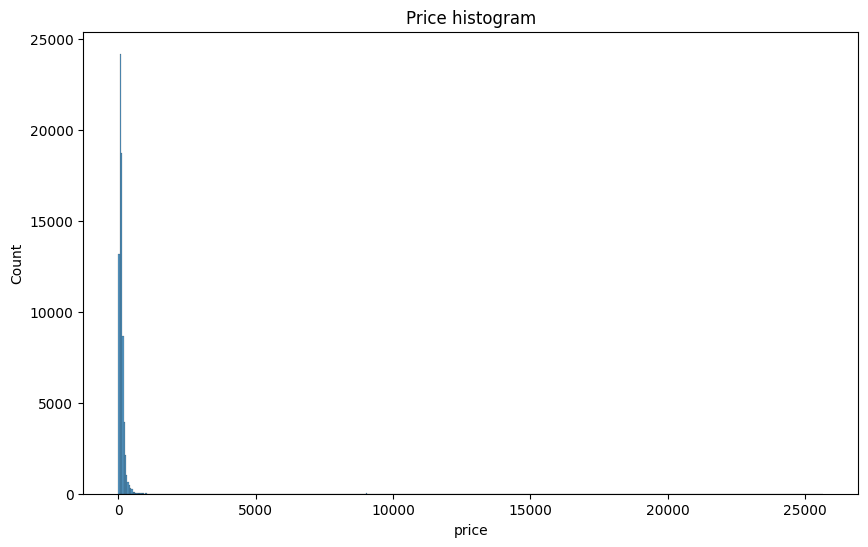

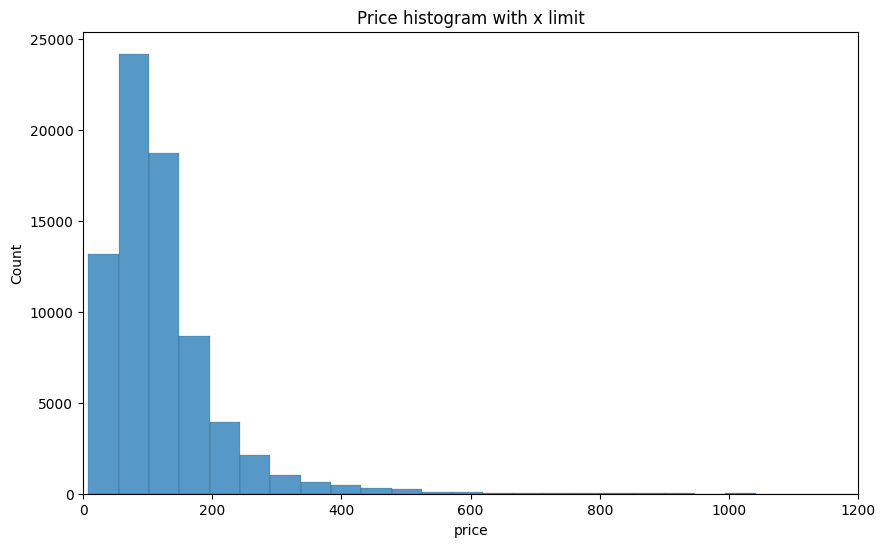

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

#histogram to visualize price distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=df_all_clean, x='price')
plt.title('Price histogram')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(data=df_all_clean, x='price')
plt.title('Price histogram with x limit')
plt.xlim(0, 1200)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

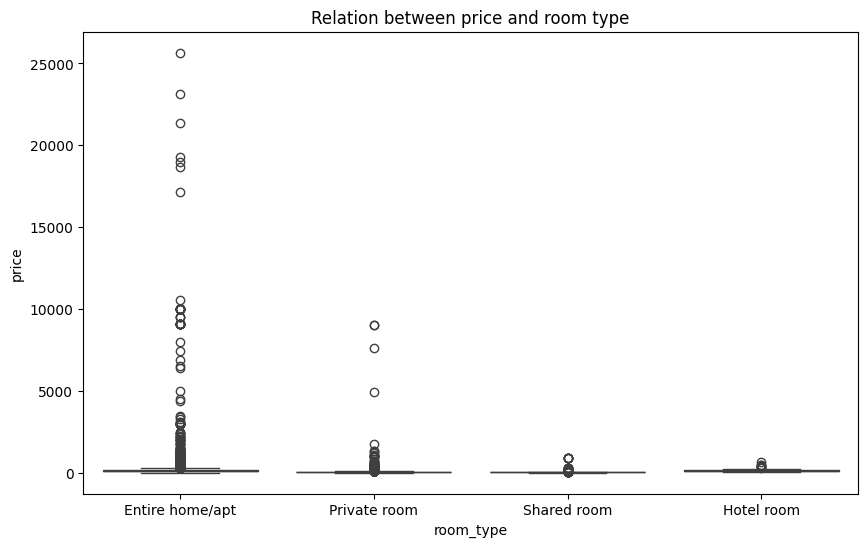

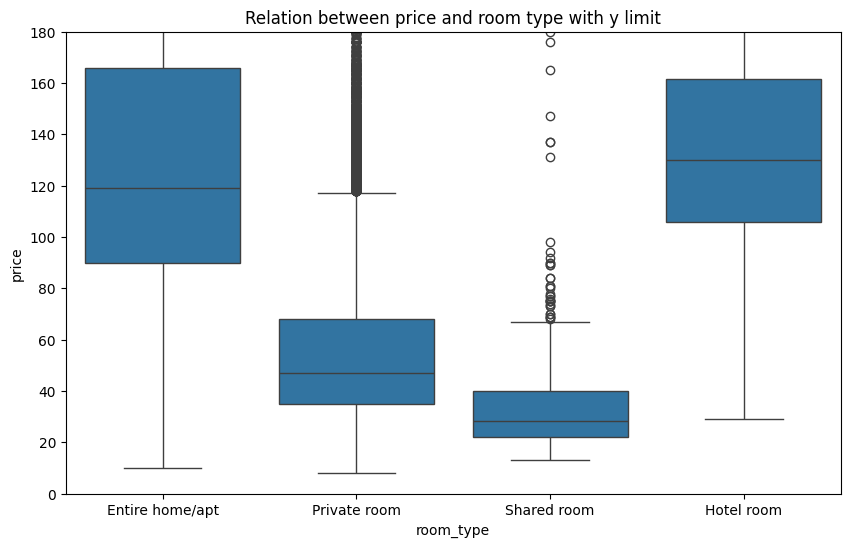

In [8]:
#boxplot to visualize price ranges for different room types
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_all_clean, x='room_type', y='price')
plt.title('Relation between price and room type')
plt.show

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_all_clean, x='room_type', y='price')
plt.title('Relation between price and room type with y limit')
plt.ylim(0, 180)
plt.show

In [10]:
#interquartile range to find price outliers for different room types
room_types = df_all_clean['room_type'].unique()
print(room_types)
df_all_clean['is_outlier_room_type'] = 0
for room in room_types:
    mask = df_all_clean['room_type'] == room
    subset_df = df_all_clean[mask]
    q1 = subset_df['price'].quantile(0.25)
    q3 = subset_df['price'].quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + (1.5 * iqr)
    lower_bound = q1 - (1.5 * iqr)
    over_bound = (subset_df['price'] > upper_bound) | (subset_df['price'] < lower_bound)
    outlier_indices = subset_df[over_bound].index
    df_all_clean.loc[outlier_indices, 'is_outlier_room_type'] = 1
    outliers_number = over_bound.sum()
    print(f'Room type: {room}')
    print(f'Upper bound: {upper_bound}')
    print(f'Lower bound: {lower_bound}')
    print(f'Outliers number: {outliers_number}')
    print("Outliers in df:", df_all_clean['is_outlier_room_type'].sum())
    print('-' * 30)

['Entire home/apt' 'Private room' 'Shared room' 'Hotel room']
Room type: Entire home/apt
Upper bound: 280.0
Lower bound: -24.0
Outliers number: 3635
Outliers in df: 3635
------------------------------
Room type: Private room
Upper bound: 117.5
Lower bound: -14.5
Outliers number: 1373
Outliers in df: 5008
------------------------------
Room type: Shared room
Upper bound: 67.0
Lower bound: -5.0
Outliers number: 50
Outliers in df: 5058
------------------------------
Room type: Hotel room
Upper bound: 245.125
Lower bound: 22.125
Outliers number: 9
Outliers in df: 5067
------------------------------


C:\Users\BSkla\AppData\Local\Temp\ipykernel_15188\2801821332.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all_clean['is_outlier_room_type'] = 0


<function matplotlib.pyplot.show(close=None, block=None)>

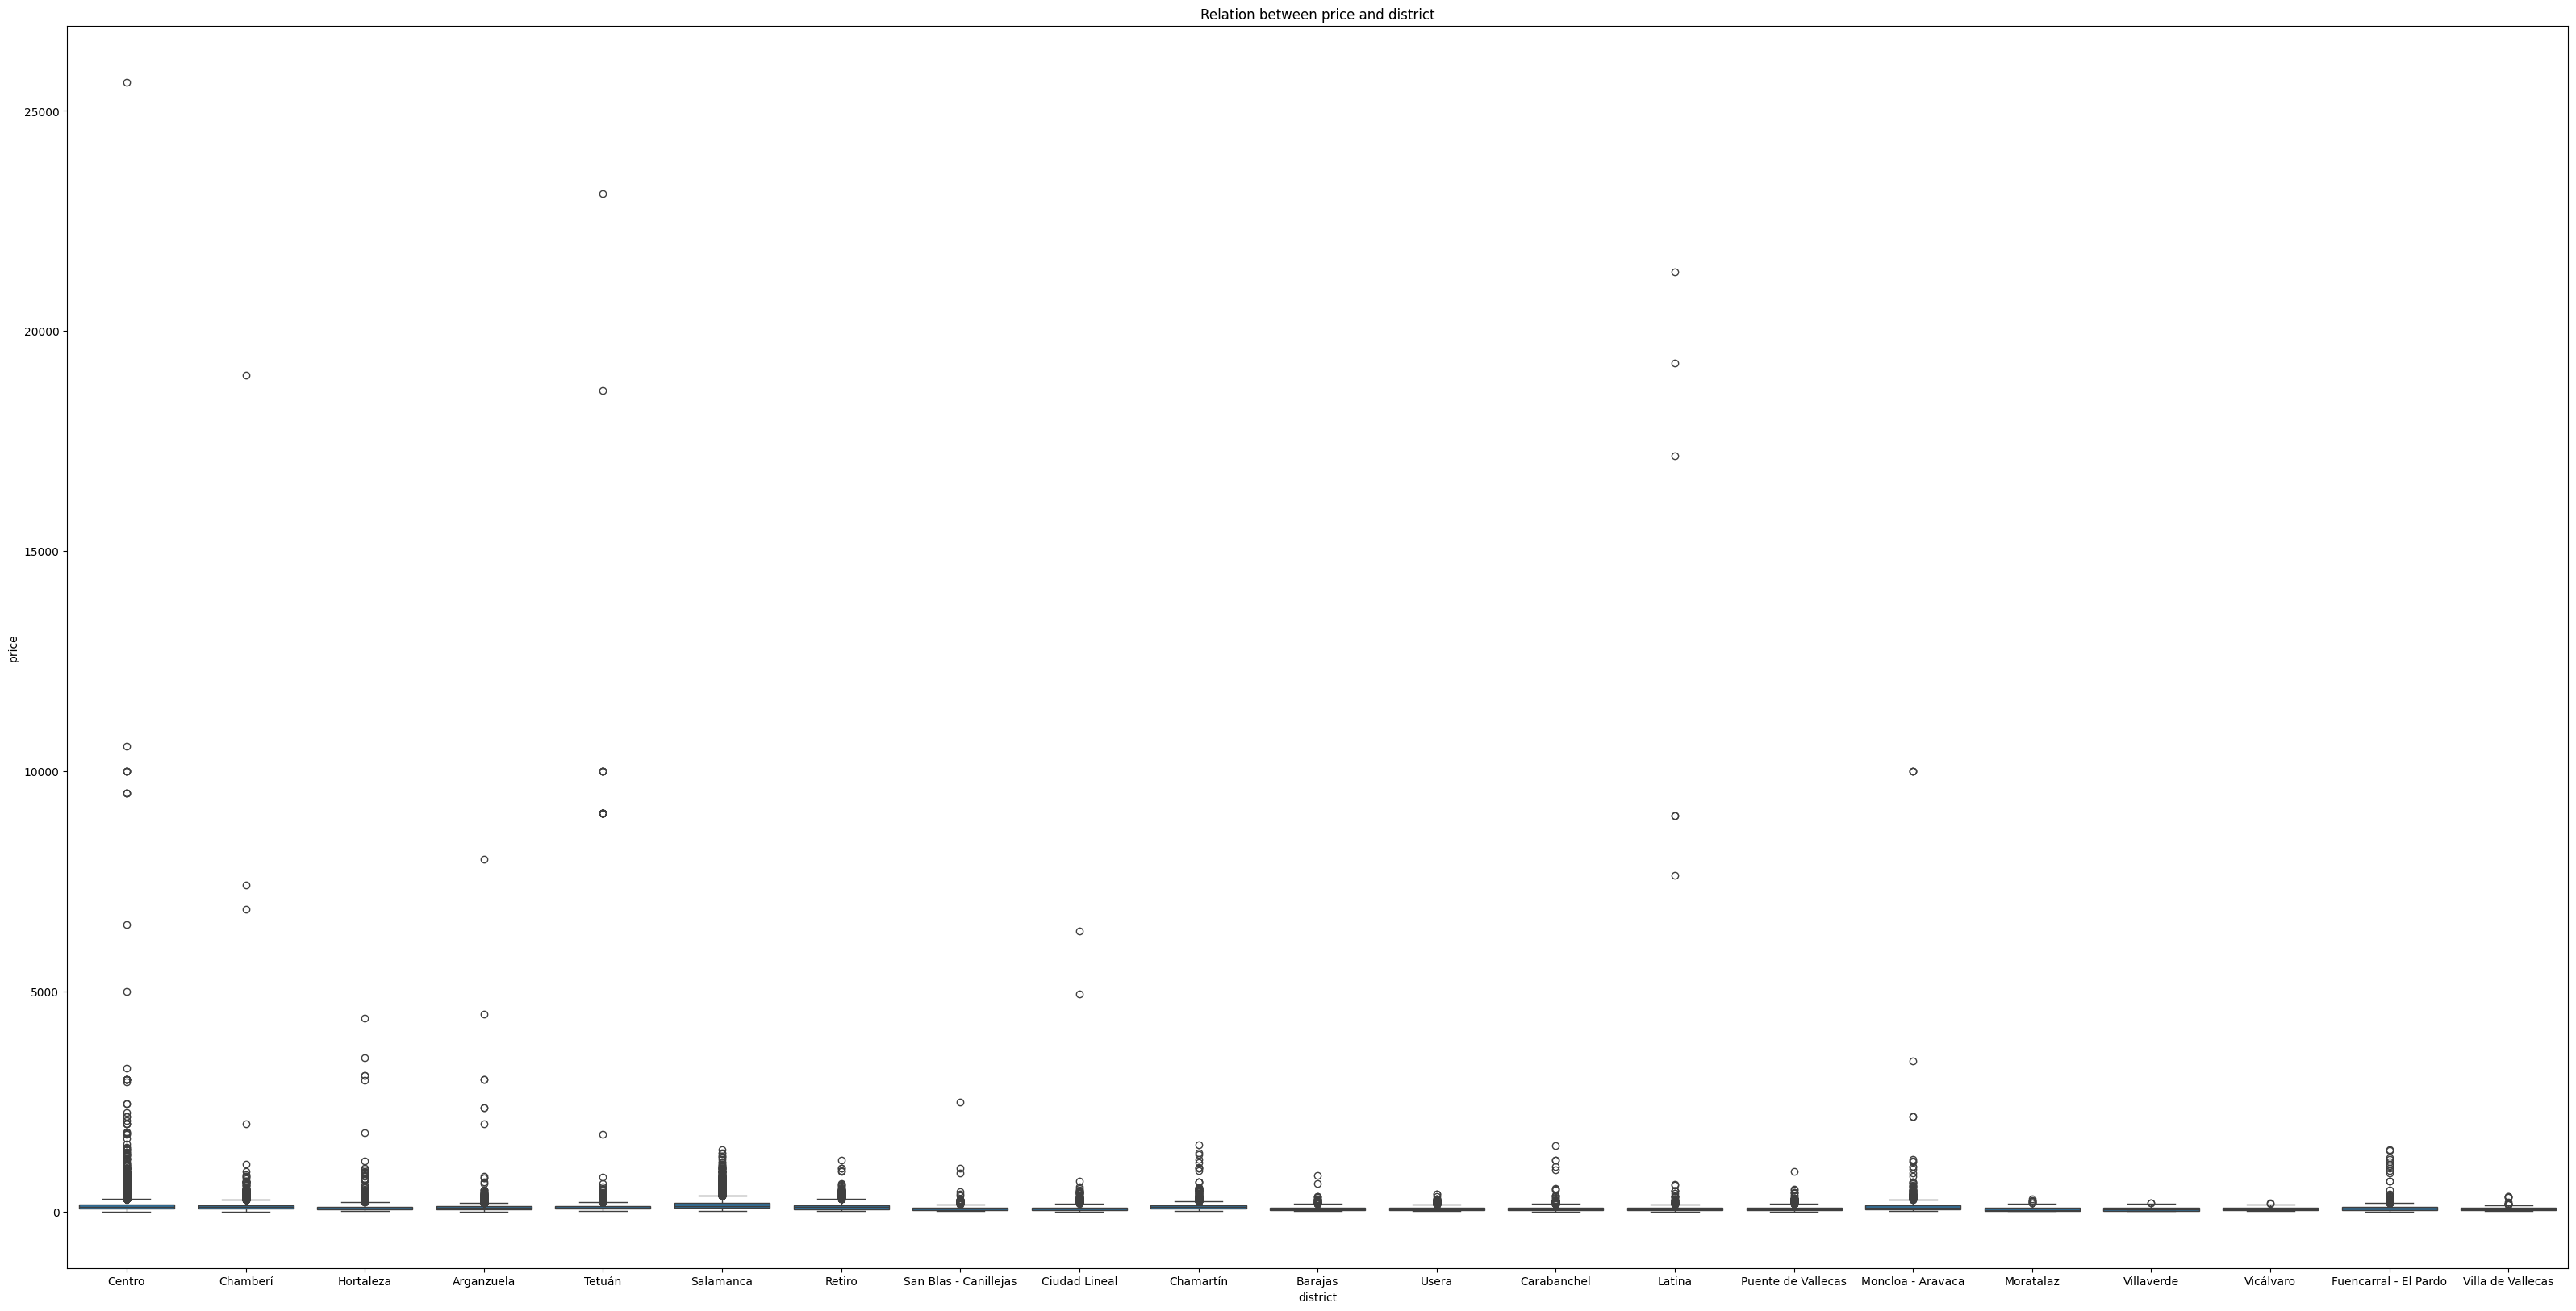

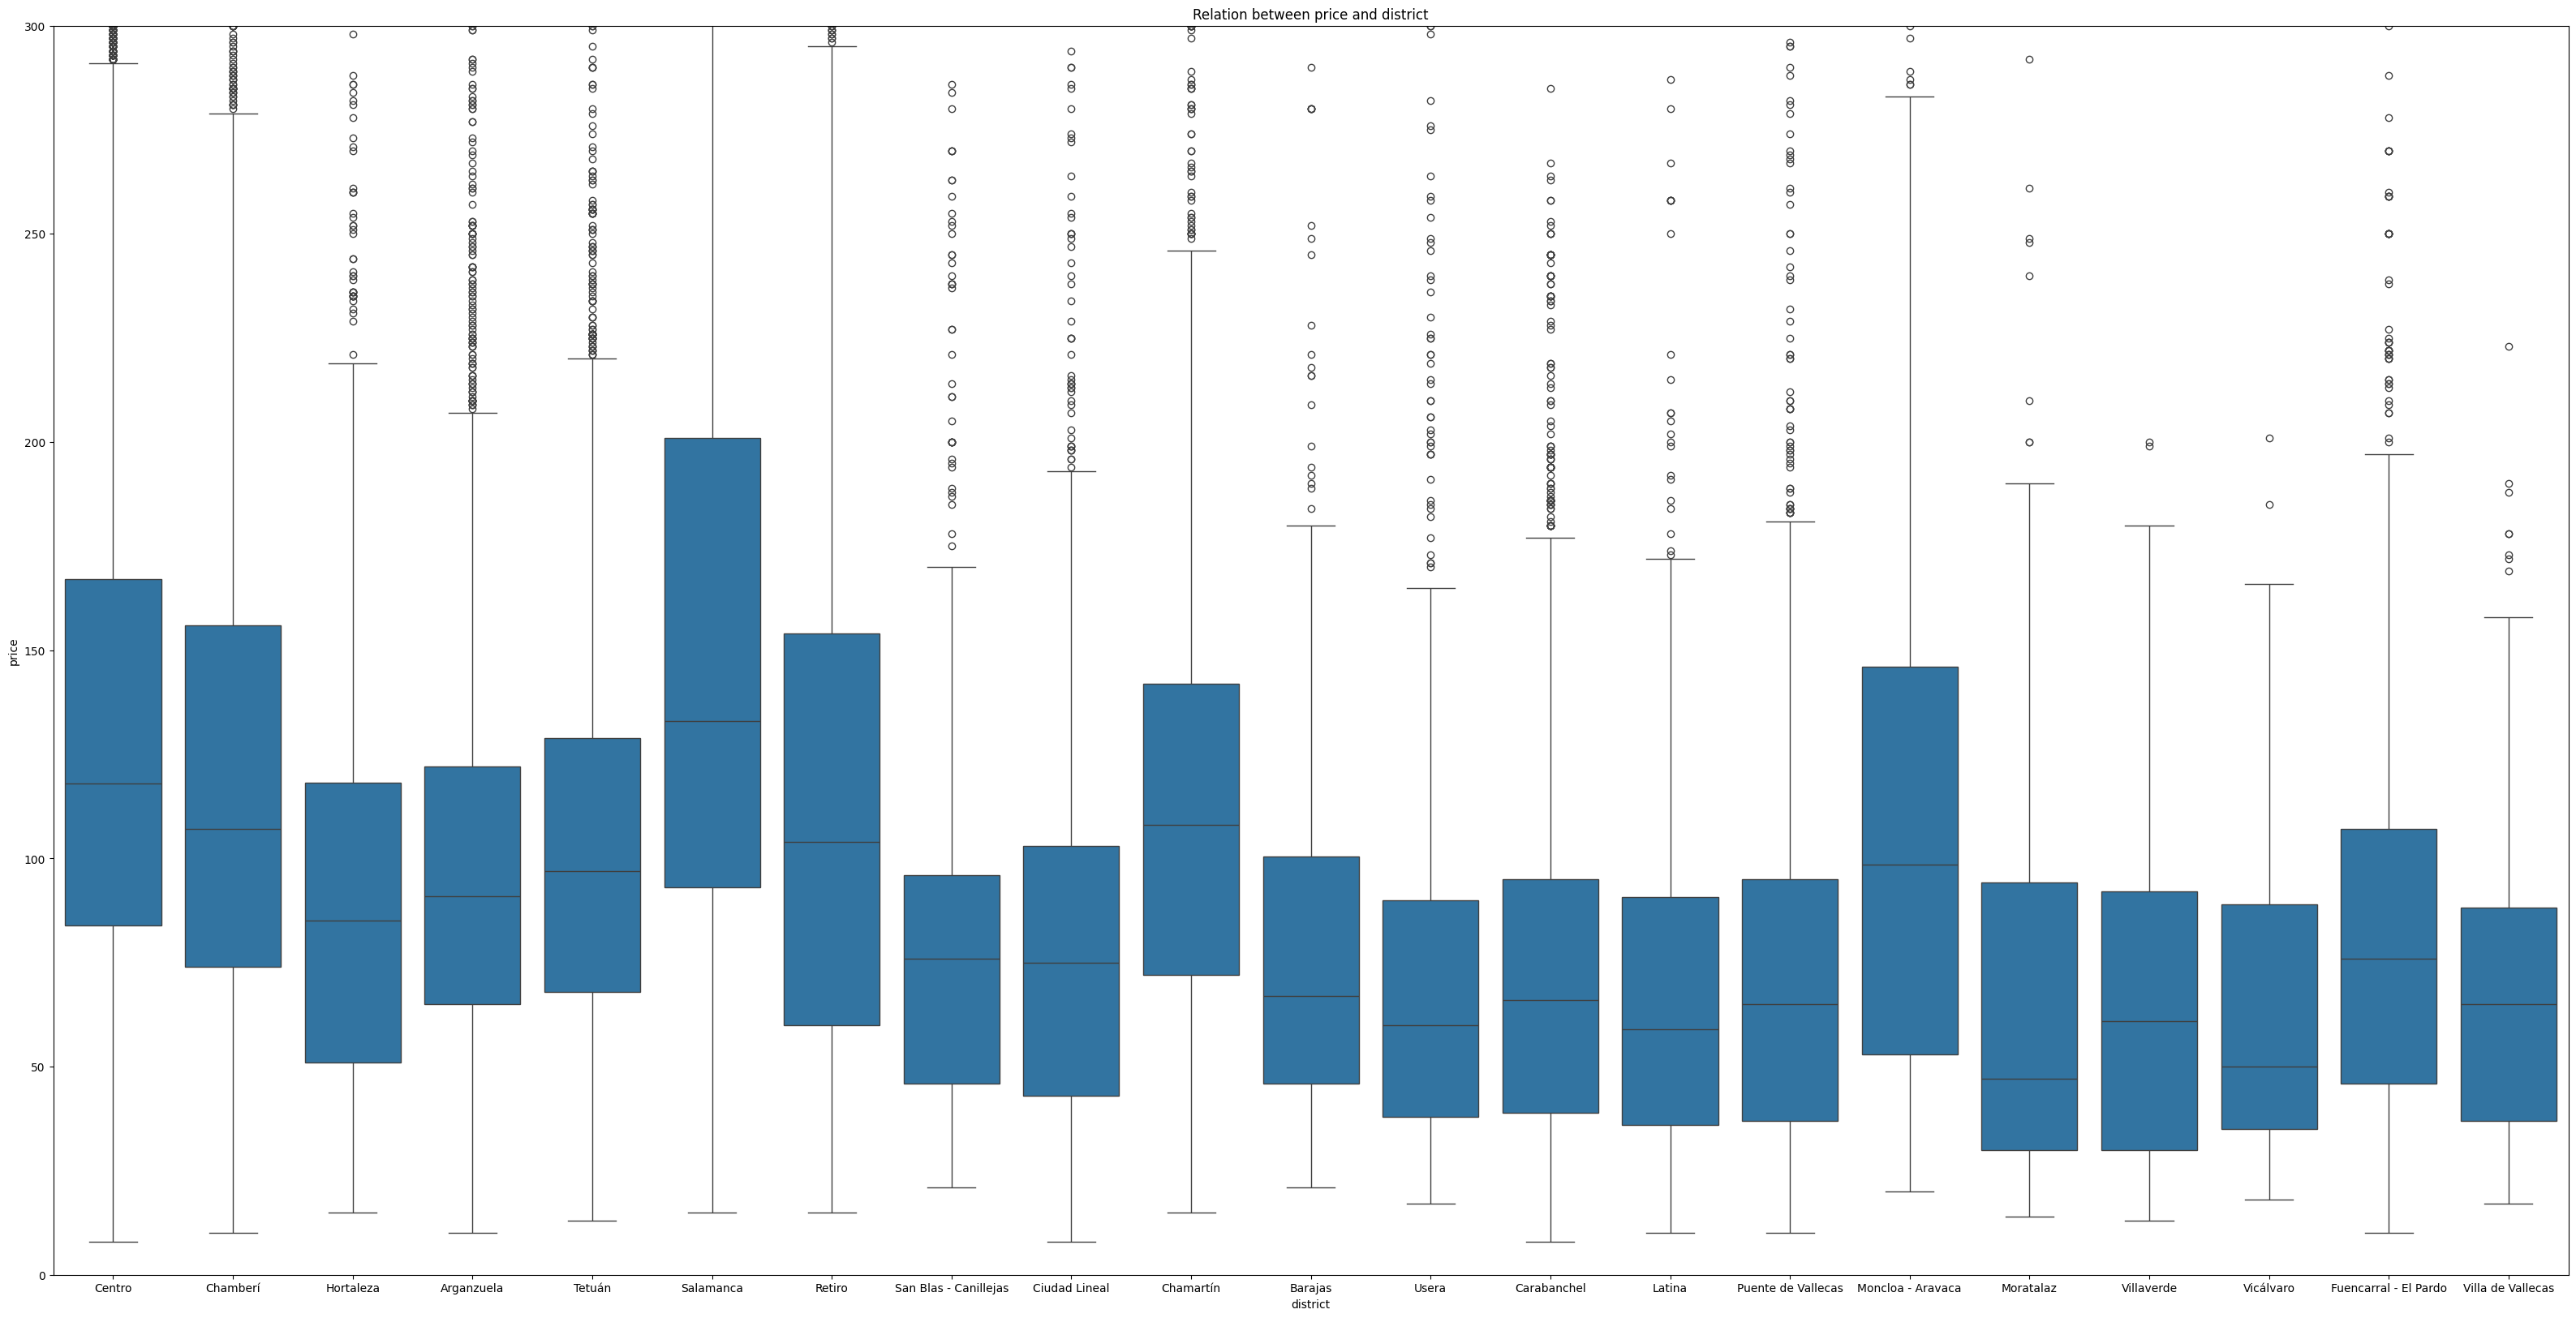

In [11]:
#neighbourhood price relations
plt.figure(figsize=(40, 20))
sns.boxplot(data=df_all_clean, x='district', y='price')
plt.title('Relation between price and district')
plt.show

plt.figure(figsize=(40, 20))
sns.boxplot(data=df_all_clean, x='district', y='price')
plt.title('Relation between price and district')
plt.ylim(0, 300)
plt.show

In [13]:
#interquartile range to find price outliers for different districts
districts = df_all_clean['district'].unique()
print(districts)
df_all_clean['is_outlier_district'] = 0
for district in districts:
    mask = df_all_clean['district'] == district
    subset_df = df_all_clean[mask]
    q1 = subset_df['price'].quantile(0.25)
    q3 = subset_df['price'].quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + (1.5 * iqr)
    lower_bound = q1 - (1.5 * iqr)
    over_bound = (subset_df['price'] > upper_bound) | (subset_df['price'] < lower_bound)
    outlier_indices = subset_df[over_bound].index
    df_all_clean.loc[outlier_indices, 'is_outlier_district'] = 1
    outliers_number = over_bound.sum()
    print(f'District: {district}')
    print(f'Upper bound: {upper_bound}')
    print(f'Lower bound: {lower_bound}')
    print(f'Outliers number: {outliers_number}')
    print('-' * 30)
print("Total # of outliers in DataFrame:", df_all_clean['is_outlier_district'].sum())

['Centro' 'Chamberí' 'Hortaleza' 'Arganzuela' 'Tetuán' 'Salamanca'
 'Retiro' 'San Blas - Canillejas' 'Ciudad Lineal' 'Chamartín' 'Barajas'
 'Usera' 'Carabanchel' 'Latina' 'Puente de Vallecas' 'Moncloa - Aravaca'
 'Moratalaz' 'Villaverde' 'Vicálvaro' 'Fuencarral - El Pardo'
 'Villa de Vallecas']
District: Centro
Upper bound: 291.5
Lower bound: -40.5
Outliers number: 2106
------------------------------
District: Chamberí
Upper bound: 279.0
Lower bound: -49.0
Outliers number: 219
------------------------------
District: Hortaleza
Upper bound: 219.125
Lower bound: -49.875
Outliers number: 94
------------------------------
District: Arganzuela
Upper bound: 207.5
Lower bound: -20.5
Outliers number: 173
------------------------------
District: Tetuán
Upper bound: 220.5
Lower bound: -23.5
Outliers number: 175
------------------------------
District: Salamanca
Upper bound: 363.0
Lower bound: -69.0
Outliers number: 322
------------------------------
District: Retiro
Upper bound: 295.0
Lower boun

C:\Users\BSkla\AppData\Local\Temp\ipykernel_15188\327959356.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all_clean['is_outlier_district'] = 0


District: Latina
Upper bound: 172.875
Lower bound: -46.125
Outliers number: 40
------------------------------
District: Puente de Vallecas
Upper bound: 182.0
Lower bound: -50.0
Outliers number: 73
------------------------------
District: Moncloa - Aravaca
Upper bound: 285.5
Lower bound: -86.5
Outliers number: 75
------------------------------
District: Moratalaz
Upper bound: 190.625
Lower bound: -66.375
Outliers number: 8
------------------------------
District: Villaverde
Upper bound: 185.0
Lower bound: -63.0
Outliers number: 2
------------------------------
District: Vicálvaro
Upper bound: 170.0
Lower bound: -46.0
Outliers number: 2
------------------------------
District: Fuencarral - El Pardo
Upper bound: 198.5
Lower bound: -45.5
Outliers number: 67
------------------------------
District: Villa de Vallecas
Upper bound: 165.125
Lower bound: -39.875
Outliers number: 12
------------------------------
Total # of outliers in DataFrame: 3890


In [14]:
df_median = df_all_clean.groupby('district')['price'].median().sort_values(ascending=False)
df_mean = df_all_clean.groupby('district')['price'].mean().sort_values(ascending=False)

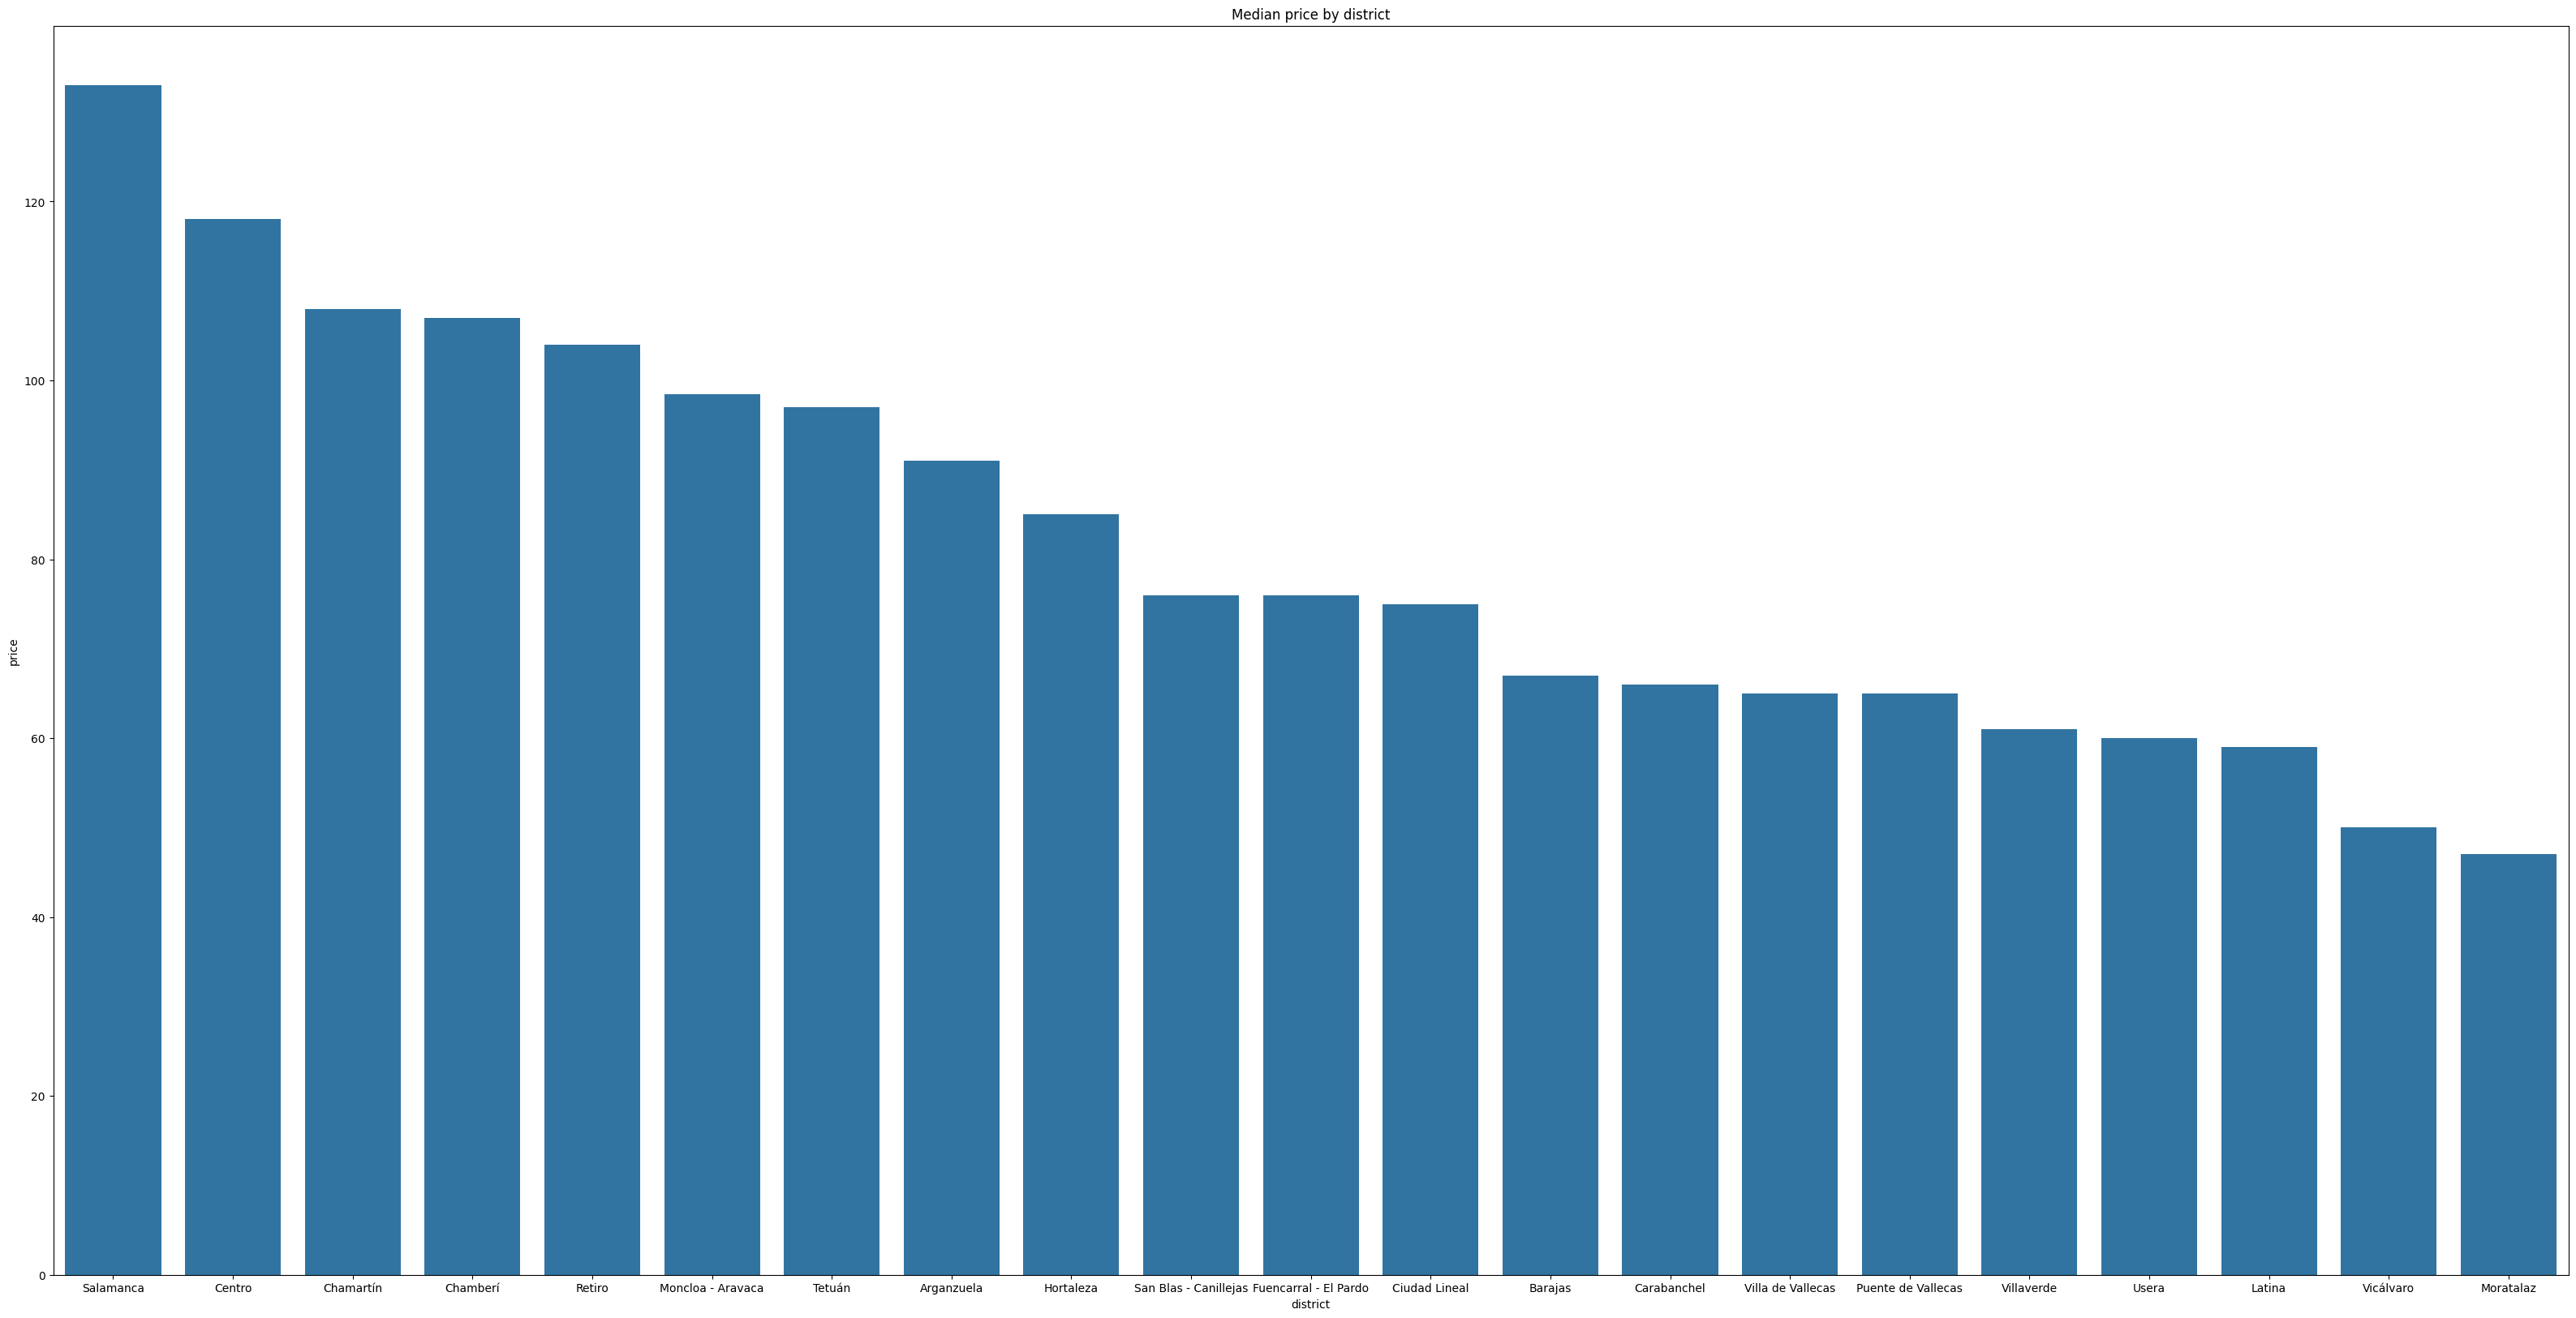

In [15]:
plt.figure(figsize=(40, 20))
sns.barplot(x='district', y='price', data=df_median.reset_index())
plt.title('Median price by district')
plt.show()

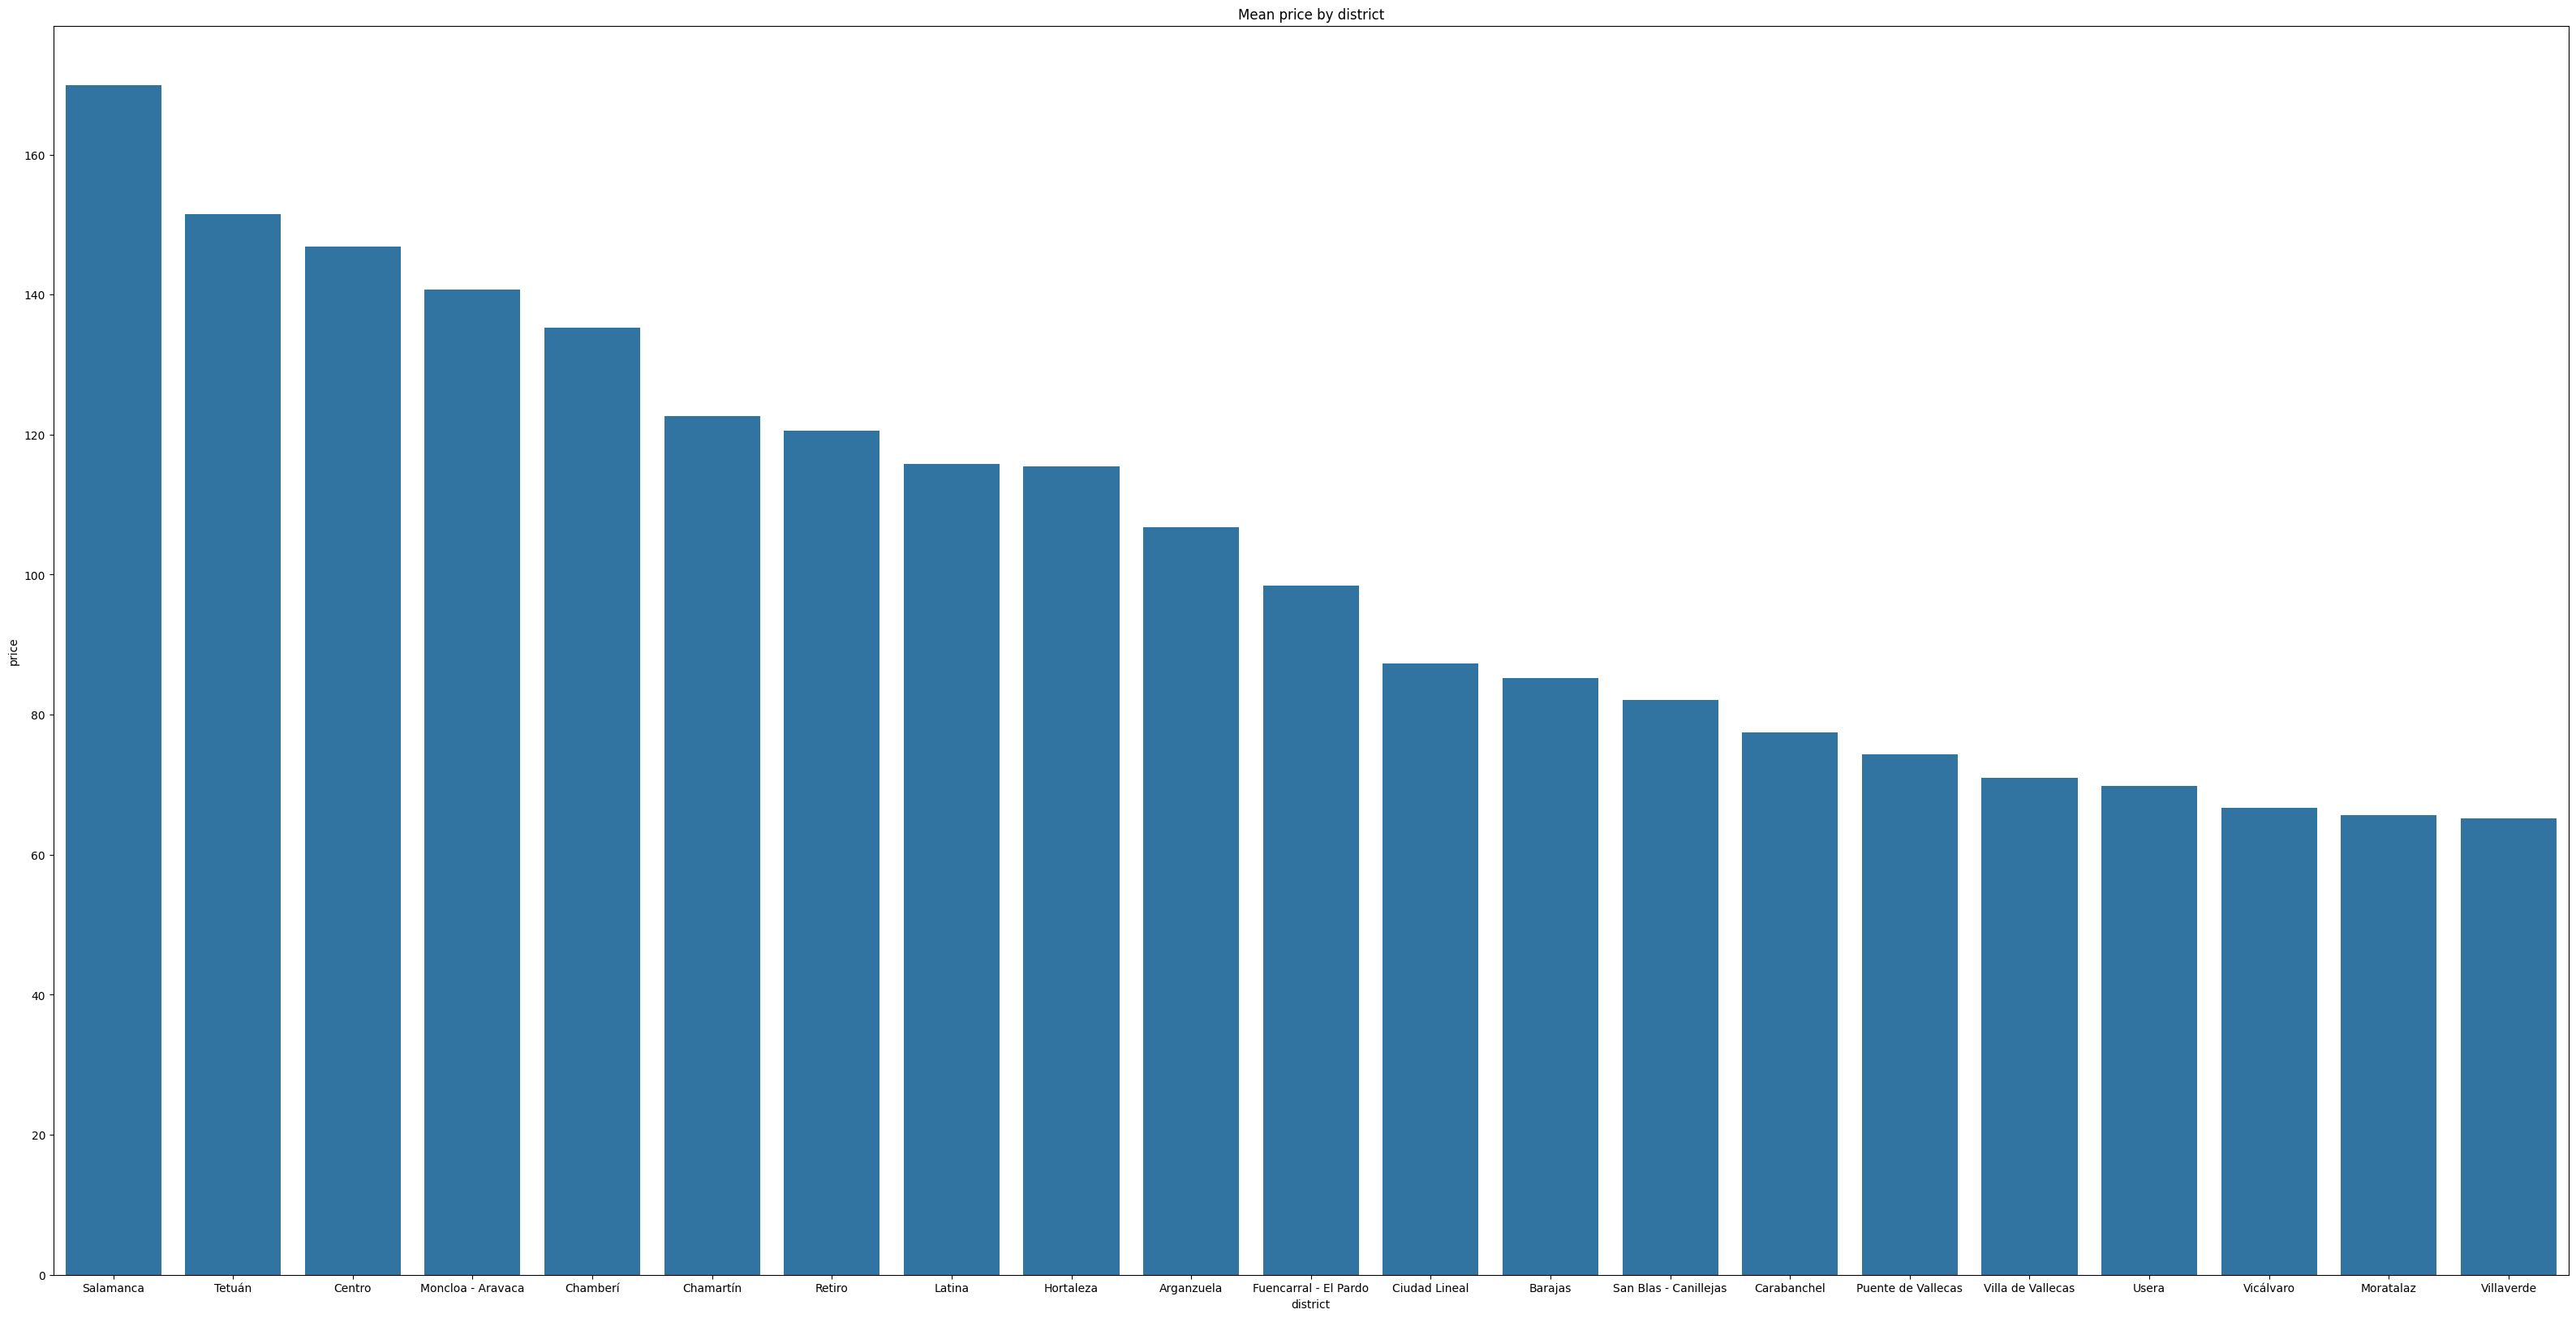

In [16]:
plt.figure(figsize=(40, 20))
sns.barplot(x='district', y='price', data=df_mean.reset_index())
plt.title('Mean price by district')
plt.show()

In [17]:
#superhost
superhosts = df_all_clean[df_all_clean['host_is_superhost'] == True].index
regular_hosts = df_all_clean[df_all_clean['host_is_superhost'] == False].index

df_all_clean.loc[superhosts, 'host_is_superhost'] = 1
df_all_clean.loc[regular_hosts, 'host_is_superhost'] = 0
df_all_clean['host_is_superhost'] = df_all_clean['host_is_superhost'].astype(int)
print(df_all_clean['host_is_superhost'].head())
print(df_all_clean['host_is_superhost'].dtype)

5    0
6    0
7    0
8    0
9    0
Name: host_is_superhost, dtype: int64
int64


C:\Users\BSkla\AppData\Local\Temp\ipykernel_15188\3136178230.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all_clean['host_is_superhost'] = df_all_clean['host_is_superhost'].astype(int)


In [18]:
df_all_clean['host_response_rate'] = df_all_clean['host_response_rate'].str.replace('%', '').astype(float)
df_all_clean['host_acceptance_rate'] = df_all_clean['host_acceptance_rate'].str.replace('%', '').astype(float)

print(df_all_clean['host_acceptance_rate'])
print(df_all_clean['host_response_rate'])

5         100.0
6          99.0
7         100.0
8          99.0
9          99.0
          ...  
100037    100.0
100055    100.0
100070    100.0
100115     69.0
100180    100.0
Name: host_acceptance_rate, Length: 74270, dtype: float64
5         100.0
6         100.0
7         100.0
8         100.0
9         100.0
          ...  
100037    100.0
100055    100.0
100070    100.0
100115     60.0
100180    100.0
Name: host_response_rate, Length: 74270, dtype: float64


C:\Users\BSkla\AppData\Local\Temp\ipykernel_15188\859398803.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all_clean['host_response_rate'] = df_all_clean['host_response_rate'].str.replace('%', '').astype(float)
C:\Users\BSkla\AppData\Local\Temp\ipykernel_15188\859398803.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all_clean['host_acceptance_rate'] = df_all_clean['host_acceptance_rate'].str.replace('%', '').astype(float)


In [19]:
#amenities
from collections import Counter

df_all_clean['amenities'] = df_all_clean['amenities'].str.replace(r'[{"\[\]}]', '', regex=True)
df_all_clean['amenities'] = df_all_clean['amenities'].str.lower()

df_all_clean['amenities_count'] = df_all_clean['amenities'].apply(lambda x: len(str(x).split(',')))
print(df_all_clean[['amenities', 'amenities_count']].head())

all_text = ','.join(df_all_clean['amenities'].dropna())
amenities_list = [x.strip() for x in all_text.split(',')]
top_20 = Counter(amenities_list).most_common(20)
print('Most popular amenities')
for item, count in top_20:
    print(f"{item}: {count}")

C:\Users\BSkla\AppData\Local\Temp\ipykernel_15188\776309350.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all_clean['amenities'] = df_all_clean['amenities'].str.replace(r'[{"\[\]}]', '', regex=True)
C:\Users\BSkla\AppData\Local\Temp\ipykernel_15188\776309350.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all_clean['amenities'] = df_all_clean['amenities'].str.lower()
C:\Users\BSkla\AppData\Local\Temp\ipykernel_15188\776309350.py:7: SettingWithCopyWarning: 
A value is trying to be set on a co

                                           amenities  amenities_count
5  tv with standard cable, elevator, air conditio...                6
6  heating, dining table, hair dryer, pets allowe...               36
7  elevator, wifi, air conditioning, tv, heating,...                6
8  cleaning products, first aid kit, hair dryer, ...               32
9  cleaning products, first aid kit, hair dryer, ...               32
Most popular amenities
wifi: 68426
kitchen: 67194
hot water: 63820
hair dryer: 59099
dishes and silverware: 58442
bed linens: 57050
iron: 56328
hangers: 56172
microwave: 54339
essentials: 54001
refrigerator: 53634
cooking basics: 52399
tv: 47165
heating: 43922
washer: 43682
shampoo: 41748
dedicated workspace: 41287
air conditioning: 40700
freezer: 38483
toaster: 35733


In [20]:
#amenities
key_amenities = ['wifi', 'kitchen', 'hot water', 'hair dryer', 'dishes and silverware', 'bed linens', 'iron', 'hangers', 'microwave',
                 'refrigerator', 'tv', 'shampoo', 'dedicated workspace', 'freezer', 'heating', 'air conditioning', 'toaster', 'washer']
for item in key_amenities:
    col_name = f'has_{item.replace(" ", "_")}'
    df_all_clean[col_name] = df_all_clean['amenities'].str.contains(item, case=False).astype(int)

C:\Users\BSkla\AppData\Local\Temp\ipykernel_15188\2727189997.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all_clean[col_name] = df_all_clean['amenities'].str.contains(item, case=False).astype(int)
C:\Users\BSkla\AppData\Local\Temp\ipykernel_15188\2727189997.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all_clean[col_name] = df_all_clean['amenities'].str.contains(item, case=False).astype(int)
C:\Users\BSkla\AppData\Local\Temp\ipykernel_15188\2727189997.py:6: SettingWithCopyWarning: 
A valu

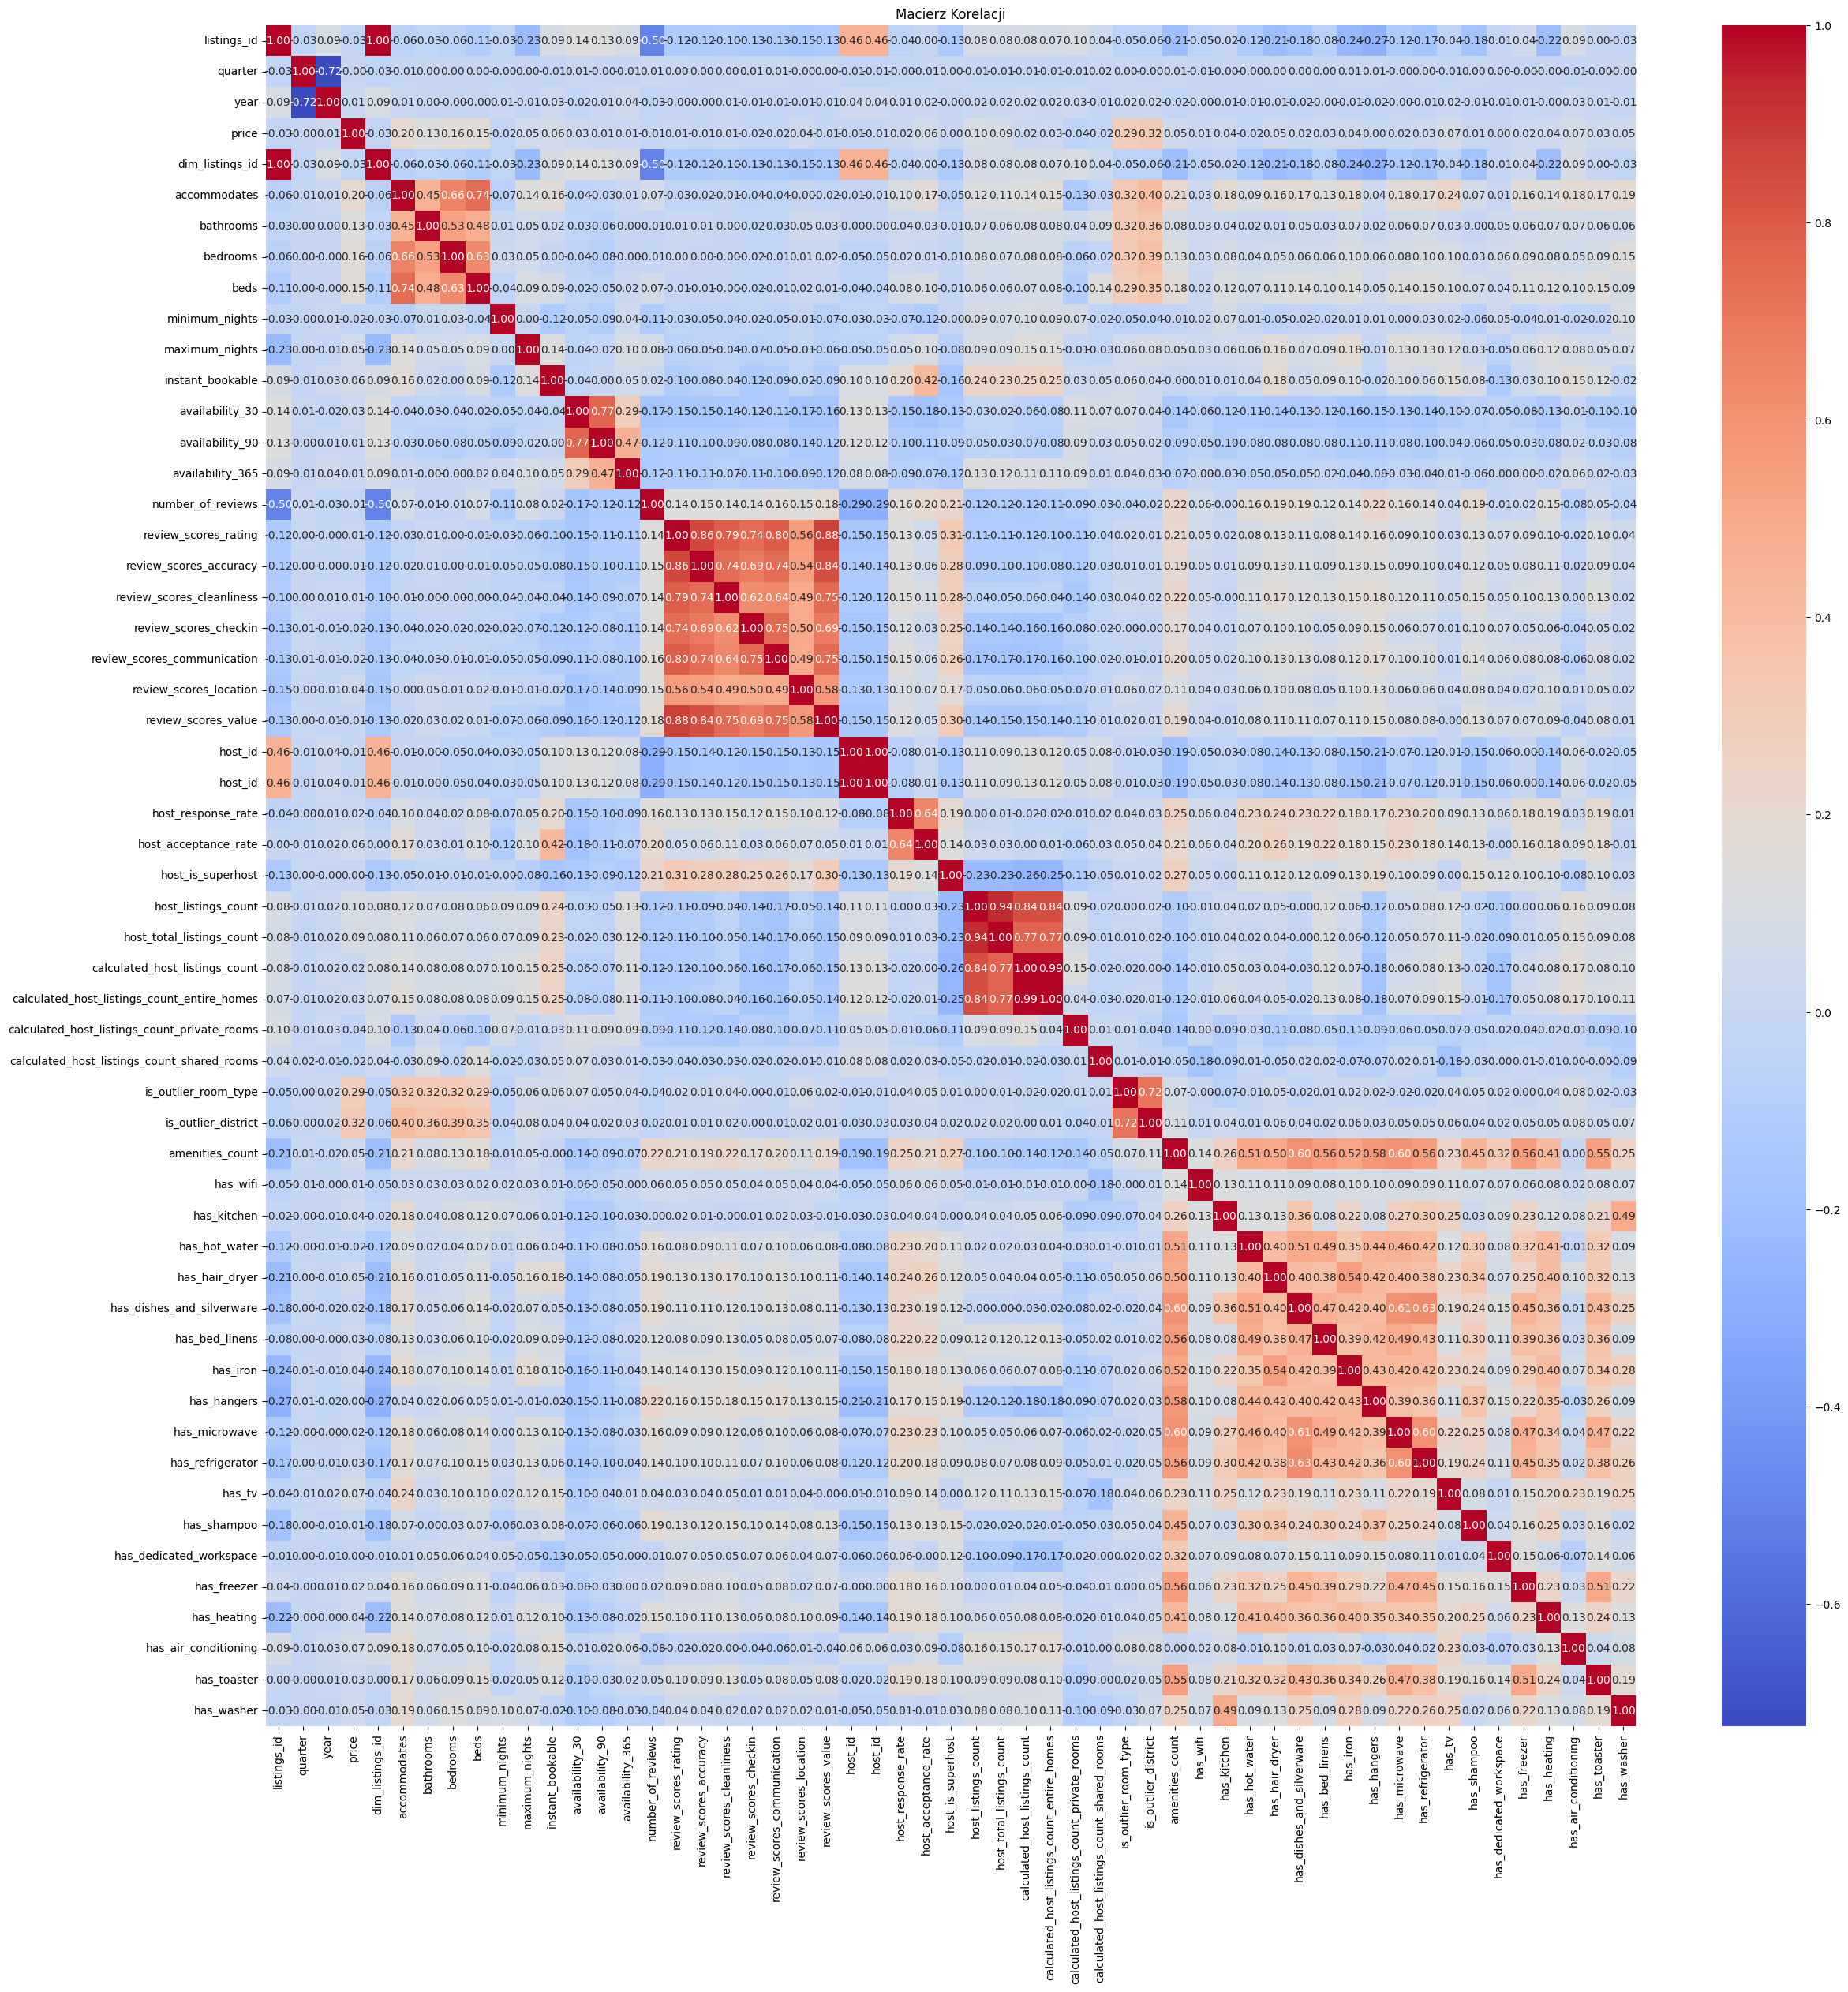

In [21]:
# heatmap to find correlations
# 1. Standardowa korelacja (liniowa) Pearson
corr_matrix=df_all_clean.corr(numeric_only=True, method='pearson')
plt.figure(figsize=(28, 28))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Macierz Korelacji")
plt.show()

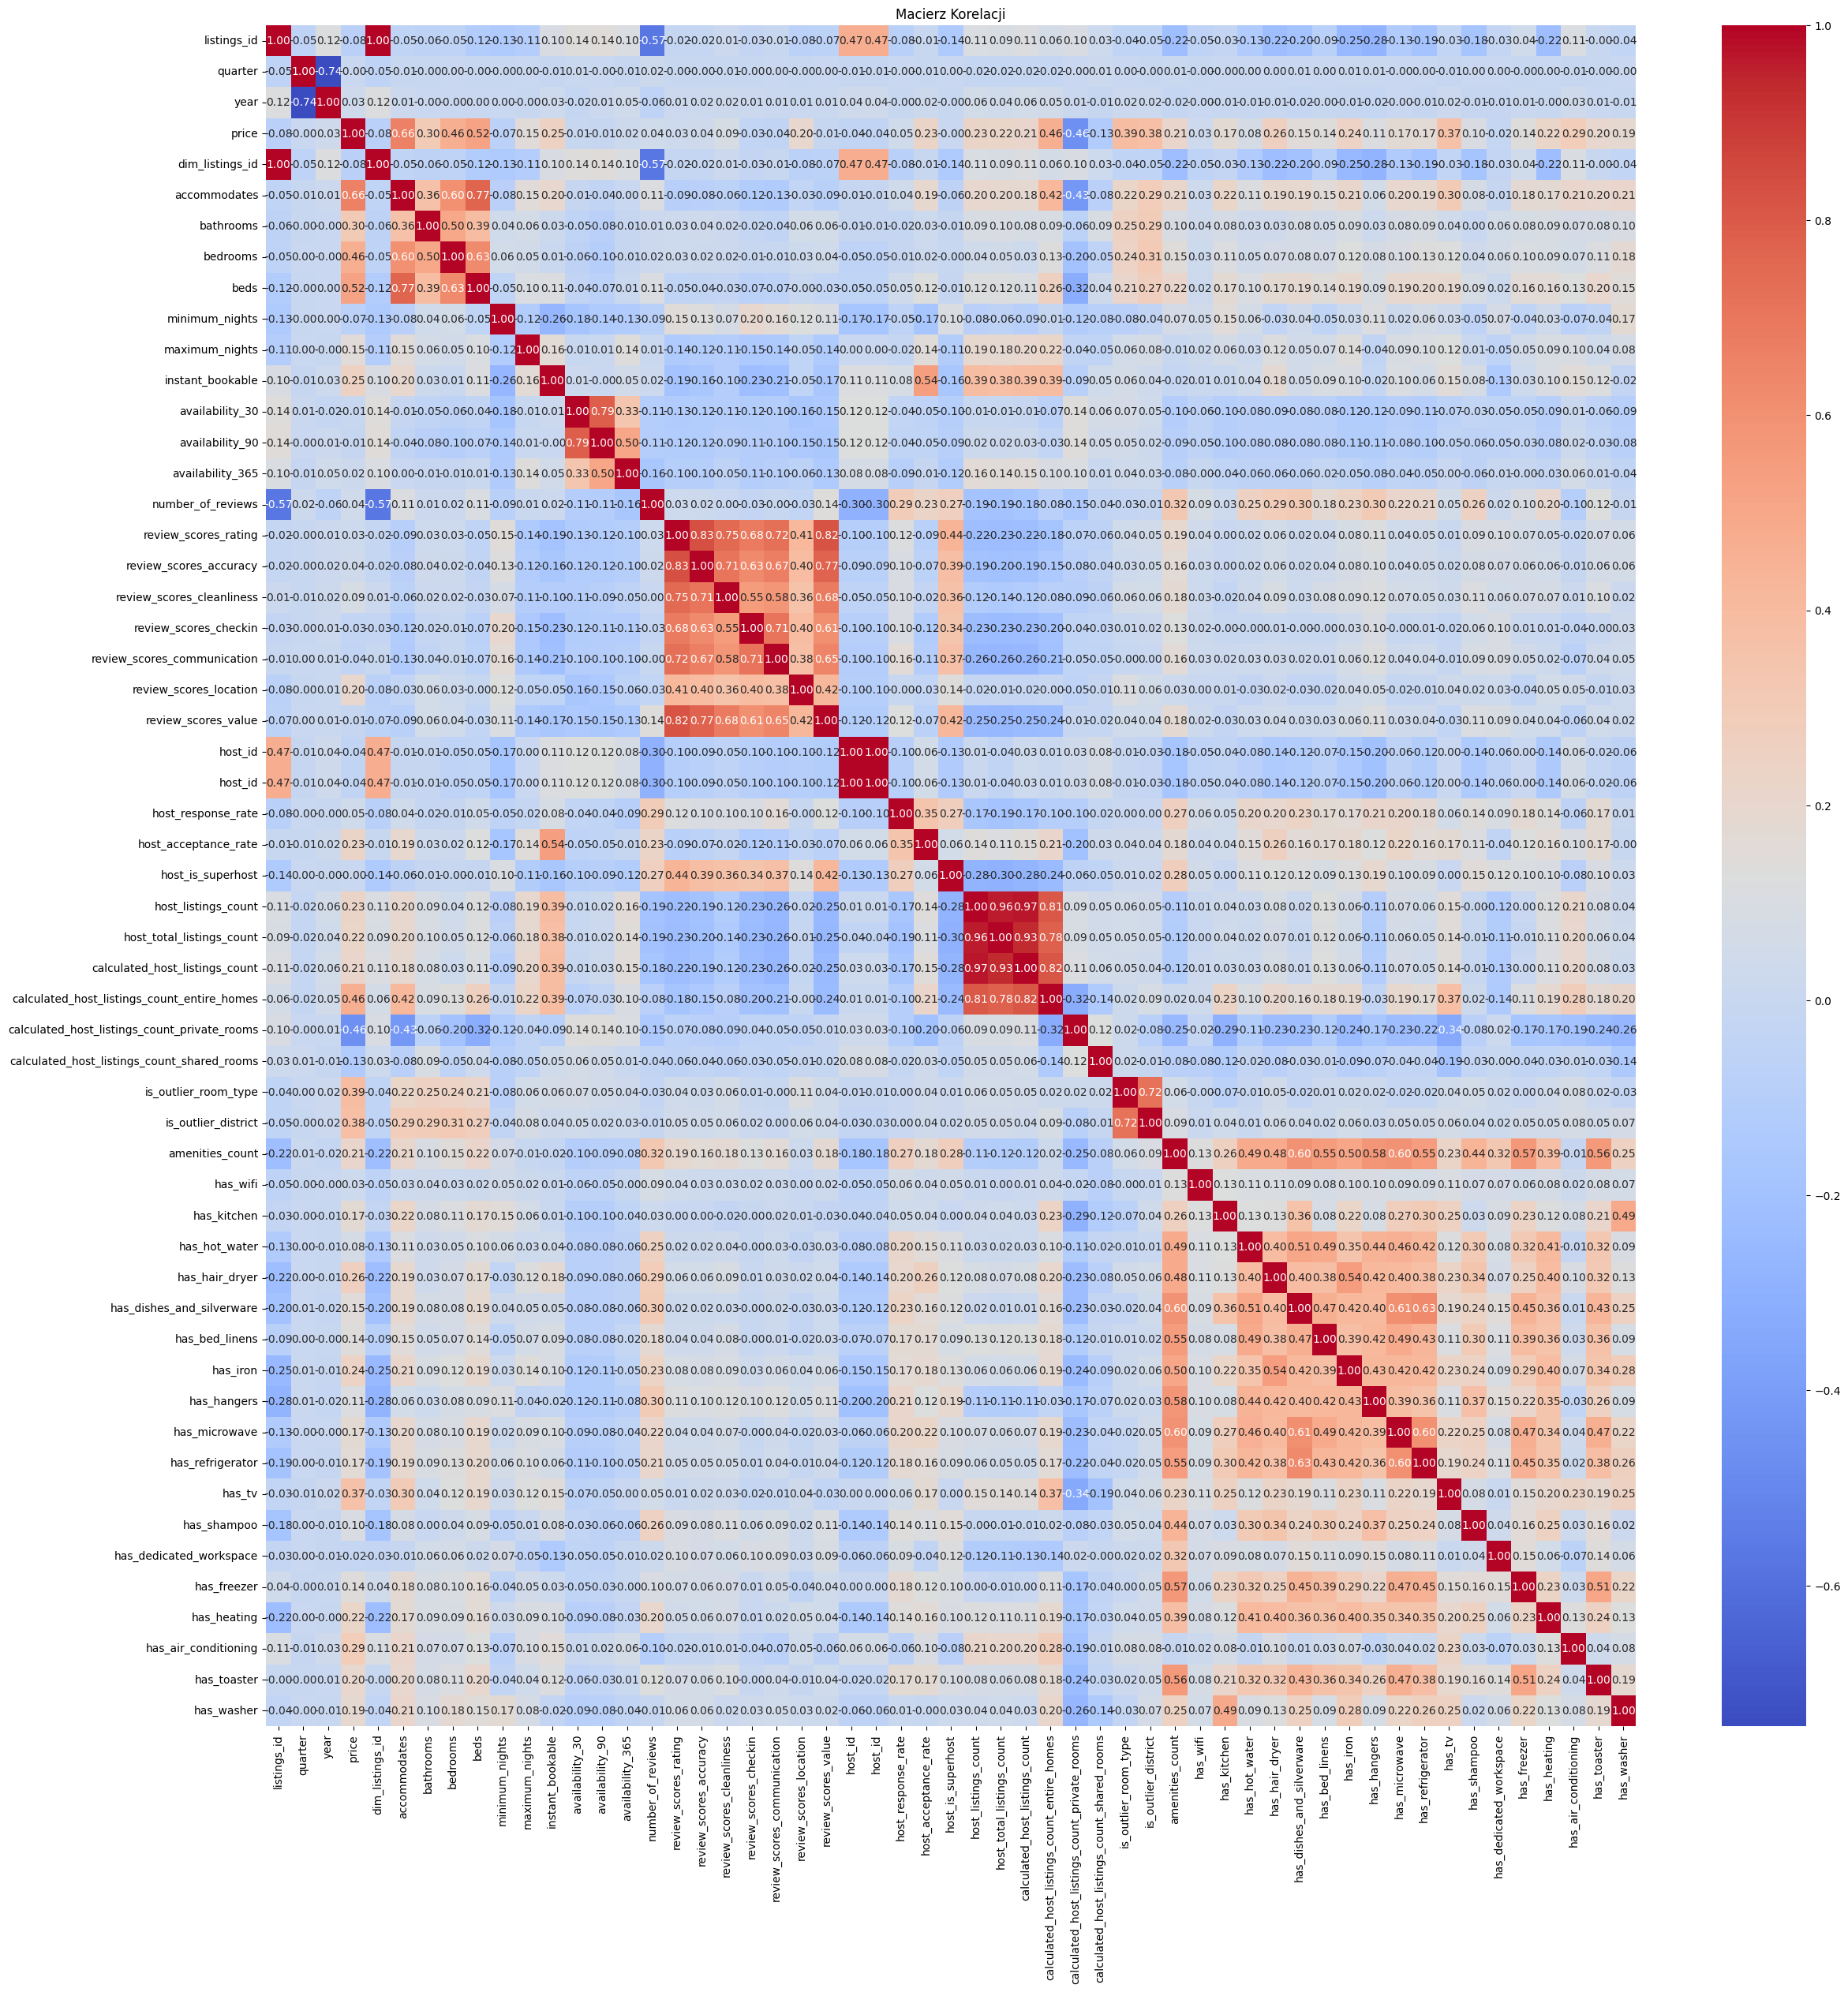

In [22]:
#Korelacja Spearman
df_corr_matrix=df_all_clean.corr(numeric_only=True, method='spearman')
plt.figure(figsize=(28, 28))
sns.heatmap(df_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Macierz Korelacji")
plt.show()

In [23]:
print("Aktualna liczba kolumn:", len(df_all_clean.columns))
df = df_all_clean.loc[:, ~df_all_clean.columns.duplicated()]

print("Aktualna liczba kolumn:", len(df.columns))

Aktualna liczba kolumn: 73
Aktualna liczba kolumn: 72


In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
#pca 
X = df[['price', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating', 
        'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location',
        'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'amenities_count', 
        'has_wifi', 'has_kitchen', 'has_heating', 'has_air_conditioning', 'has_toaster', 'has_washer', 'has_dishes_and_silverware', 'has_bed_linens', 
        'has_iron', 'has_microwave', 'has_tv', 'has_refrigerator', 'has_shampoo', 'has_dedicated_workspace', 'has_freezer']]

scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_standardized)
df_pca = pd.DataFrame(
    data=principal_components,
    columns=['PC1_home_appliances', 'PC2_CSAT_vs_listing_size'],
    index=df.index)
df_final = pd.concat([df, df_pca], axis=1)

explained_variance = pca.explained_variance_ratio_
print("Explained variance ratio:", explained_variance)
print("Sum:", explained_variance.sum())

loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=['PC1', 'PC2']
)
print(loadings)
print(f"Oryginał: {df.shape}")
print(f"Finalny: {df_final.shape}")

Explained variance ratio: [0.20078804 0.13288042]
Sum: 0.3336684641220211
                                  PC1       PC2
price                        0.032832 -0.050795
accommodates                 0.128548 -0.194758
bathrooms                    0.064069 -0.107125
bedrooms                     0.086272 -0.142620
beds                         0.110948 -0.163183
number_of_reviews            0.114474  0.048410
review_scores_rating         0.207791  0.373977
review_scores_accuracy       0.201199  0.359013
review_scores_cleanliness    0.202075  0.325113
review_scores_checkin        0.174714  0.348151
review_scores_communication  0.193864  0.350546
review_scores_location       0.147396  0.268506
host_response_rate           0.159542 -0.008784
host_acceptance_rate         0.142058 -0.047675
host_is_superhost            0.131898  0.132972
amenities_count              0.320679 -0.110123
has_wifi                     0.067948 -0.016354
has_kitchen                  0.138838 -0.130284
has_heating   

In [25]:
duplikaty = df.columns[df.columns.duplicated()]
print("Zduplikowane kolumny:", duplikaty)

Zduplikowane kolumny: Index([], dtype='object')


In [26]:
df_final.to_parquet('clean_data.parquet', engine='pyarrow', index=False)